In [1]:
# --- Interactive Environment ---
%matplotlib inline

# --- Standard Library ---
import os
import re
import glob
import json
import pickle
from pathlib import Path
from datetime import datetime
from typing import Sequence, Optional, Tuple, Dict, Union
from dataclasses import dataclass
from itertools import combinations

# --- Third-Party Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import colormaps
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.colors import Normalize, LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.lines import Line2D
from scipy import stats
from scipy.stats import linregress, mannwhitneyu, spearmanr, pearsonr, wilcoxon, binomtest, norm, fisher_exact
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from trimesh import load_mesh

# --- Local / Project Imports ---
from aind_dynamic_foraging_basic_analysis.licks.lick_analysis import load_nwb
from aind_analysis_arch_result_access.han_pipeline import get_mle_model_fitting
from aind_dynamic_foraging_behavior_video_analysis.kinematics.tongue_analysis import (
    get_session_name_from_path,
    session_already_done,
)
from aind_dynamic_foraging_behavior_video_analysis.kinematics.tongue_kinematics_utils import (
    annotate_movement_timing,
    add_lick_metadata_to_movements,
)
from aind_dynamic_foraging_behavior_video_analysis.ephys.tongue_ephys import (
    get_events_dict,
    build_event_df,
    plot_unit_panels,
    RasterPlotter,
    compute_psth,
    smooth_vector,
    plot_psth,
    find_session_dir,
    load_intermediate_data,
    get_session_prefix,
)
from ccf_utils import pir_to_lps, project_to_plane

FIG_DIR = Path("/root/capsule/scratch/figures/ephys_kinematics_panels/fig_panels")
fig_dir = FIG_DIR
SAVE_FIG = True

In [2]:
#load ephys data
with open('/root/capsule/data/LCrecordings_combined_units/combined_unit_tbl.pkl', 'rb') as file:
    combined_ephys_data = pickle.load(file)

In [3]:
from pathlib import Path
import json
import pandas as pd

# ---- criteria ----
COVERAGE_MIN = 90.0
DURATION50_MIN = 0.06  # seconds

# # ---- roots to scan ----
# base_dirs = [
#     Path("/root/capsule/data/keypoint_tracking_bottomview_LCrecordings_OOD"),
#     Path("/root/capsule/data/keypoint_tracking_bottomview_LCrecordings_ID"),
# ]

base_dirs = [Path("/root/capsule/data/keypoint_tracking_bottomview_LCrecordings_20260403")]

rows_pass = []
rows_fail = []

for base_dir in base_dirs:
    if not base_dir.exists():
        continue
    for subdir in base_dir.iterdir():
        if not (subdir.is_dir() and session_already_done(subdir)):
            continue

        json_file = subdir / "tongue_quality_stats.json"
        try:
            with open(json_file, "r") as f:
                d = json.load(f)
        except Exception as e:
            print(f"Skipping {subdir} (couldn't read JSON): {e}")
            continue

        cov = float(d.get("coverage_pct", 0.0))
        dur50 = float(d.get("percentiles", {}).get("duration", {}).get("0.5", 0.0))

        row = {
            "session_path": subdir,
            "json_path": json_file,
            "session_id": d.get("session_id", subdir.name),
            "coverage_pct": cov,
            "duration_p50": dur50,
        }

        if cov > COVERAGE_MIN and dur50 > DURATION50_MIN:
            rows_pass.append(row)
        else:
            rows_fail.append(row)

# ---- results: sessions meeting criteria ----
filtered_df = pd.DataFrame(rows_pass).sort_values(
    ["coverage_pct", "duration_p50"], ascending=[False, False]
)

print(
    f"Sessions meeting criteria (coverage>{COVERAGE_MIN}, "
    f"median duration>{DURATION50_MIN}s): {len(filtered_df)}"
)
for _, r in filtered_df.iterrows():
    print(
        f"{r['session_path']}  "
        f"(coverage={r['coverage_pct']:.1f}%, median_dur={r['duration_p50']:.3f}s)"
    )

filtered_session_paths = filtered_df["session_path"].tolist()

# ---- results: sessions NOT meeting criteria ----
failed_df = pd.DataFrame(rows_fail).sort_values(
    ["coverage_pct", "duration_p50"], ascending=[False, False]
)

print(
    f"\nSessions NOT meeting criteria "
    f"(coverage<={COVERAGE_MIN} or median duration<={DURATION50_MIN}s): {len(failed_df)}"
)
for _, r in failed_df.iterrows():
    print(
        f"{r['session_path']}  "
        f"(coverage={r['coverage_pct']:.1f}%, median_dur={r['duration_p50']:.3f}s)"
    )


Sessions meeting criteria (coverage>90.0, median duration>0.06s): 44
/root/capsule/data/keypoint_tracking_bottomview_LCrecordings_20260403/behavior_782394_2025-04-23_10-51-14  (coverage=100.0%, median_dur=0.074s)
/root/capsule/data/keypoint_tracking_bottomview_LCrecordings_20260403/behavior_782394_2025-04-24_12-07-31  (coverage=100.0%, median_dur=0.072s)
/root/capsule/data/keypoint_tracking_bottomview_LCrecordings_20260403/behavior_782394_2025-04-25_11-13-18  (coverage=100.0%, median_dur=0.072s)
/root/capsule/data/keypoint_tracking_bottomview_LCrecordings_20260403/behavior_761038_2025-04-15_10-24-57  (coverage=99.9%, median_dur=0.074s)
/root/capsule/data/keypoint_tracking_bottomview_LCrecordings_20260403/behavior_791691_2025-06-27_13-54-27  (coverage=99.9%, median_dur=0.068s)
/root/capsule/data/keypoint_tracking_bottomview_LCrecordings_20260403/behavior_752014_2025-03-28_11-04-56  (coverage=99.9%, median_dur=0.092s)
/root/capsule/data/keypoint_tracking_bottomview_LCrecordings_20260403/

In [4]:

#filter units by session and quality criteria

DEFAULT_CRITERIA = {
    "isi_violations": {"bounds": [0.0, 0.1]},
    "p_max":         {"bounds": [0.5, 1.0]},
    "lat_max_p":     {"bounds": [0.005, 0.02]},
    "eu":            {"bounds": [0.0, 0.25]},
    "corr":          {"bounds": [0.95, 1.0]},
    "qc_pass":       {"items":  [True]},
    "peak":          {"bounds": [-1000, 0]},
    "trial_count":   {"bounds": [100, 2000]},
    "in_df":         {"items":  [True]},
}

def filter_by_criteria(df: pd.DataFrame, criteria: dict = None) -> pd.DataFrame:
    if criteria is None:
        criteria = DEFAULT_CRITERIA
    mask = pd.Series(True, index=df.index)
    for col, rule in criteria.items():
        if "bounds" in rule:
            lo, hi = rule["bounds"]
            mask &= df[col].between(lo, hi, inclusive="both")
        if "items" in rule:
            mask &= df[col].isin(rule["items"])
    return df.loc[mask].copy()

# =========================
# 1) get session ids
# =========================
# done_sessions should already be defined
session_order_full   = [get_session_name_from_path(str(p)) for p in filtered_session_paths]
session_prefix_order = [get_session_prefix(s) for s in session_order_full]
session_prefix_allow = set(session_prefix_order)

# =========================
# 2) filter ephys
# =========================
# ensure session_prefix exists on both tables
combined_ephys_data = combined_ephys_data.copy()
combined_ephys_data["session_prefix"] = combined_ephys_data["session"].map(get_session_prefix)

criteria_filtered = filter_by_criteria(combined_ephys_data, DEFAULT_CRITERIA)

# final filtered units = criteria + allowed session prefixes
filtered_ephys = criteria_filtered.loc[
    criteria_filtered["session_prefix"].isin(session_prefix_allow)
].copy()

# =========================
# 3) session summary
# =========================
counts_before = combined_ephys_data.groupby("session_prefix").size().rename("units_before")
counts_after  = criteria_filtered.groupby("session_prefix").size().rename("units_after")

base = pd.concat([counts_before, counts_after], axis=1).reindex(session_prefix_order)
base["units_before"] = base["units_before"].astype("Int64")        # keep NA if not present before
base["units_after"]  = base["units_after"].fillna(0).astype(int)   # 0 if none survived

session_summary = base.reset_index().rename(columns={"index": "session_prefix"})

# =========================
# prints / outputs
# =========================
print(f"Filtered units: {len(filtered_ephys)} / {len(combined_ephys_data)}")
print(session_summary.to_string(index=False))

# =========================
# QC-only vs session-filtered counts
# =========================
n_qc_all_sessions = len(criteria_filtered)
n_qc_allowed_sessions = len(filtered_ephys)
n_excluded_by_session = n_qc_all_sessions - n_qc_allowed_sessions

print(
    f"QC-pass units (all sessions): {n_qc_all_sessions}\n"
    f"QC-pass units (allowed sessions only): {n_qc_allowed_sessions}\n"
    f"QC-pass units excluded by session filter: {n_excluded_by_session}"
)



Filtered units: 104 / 18300
            session_prefix  units_before  units_after
behavior_782394_2025-04-23           243            9
behavior_782394_2025-04-24           394            7
behavior_782394_2025-04-25           116            0
behavior_761038_2025-04-15           435            2
behavior_791691_2025-06-27           265            4
behavior_752014_2025-03-28           254            1
behavior_751769_2025-01-16           229            1
behavior_716325_2024-05-31           281            3
behavior_758017_2025-02-06           127            1
behavior_782394_2025-04-22           270            0
behavior_758017_2025-02-07           231            4
behavior_751769_2025-01-18           255            5
behavior_754897_2025-03-14           117            5
behavior_784803_2025-07-01           357            3
behavior_784803_2025-07-02           375            0
behavior_751004_2024-12-20           248            3
behavior_751766_2025-02-11           277            5


In [5]:
#load individual ephys data with spike times

ROOT_SCRATCH = "/root/capsule/data/LC-NE_scratch_data_1"

def get_animal_id(session: str) -> str:
    m = re.match(r'^behavior_(\d+)_', session)
    if not m:
        raise ValueError(f"Cannot parse animal id from session: {session}")
    return m.group(1)

def find_summary_pkl(root: str, session: str) -> Optional[Path]:  # <-- fixed
    """Try exact path; if missing, fall back to prefix glob search."""
    animal = get_animal_id(session)
    exact = Path(root) / animal / session / "ephys" / "opto" / "curated" / f"{session}_curated_soma_opto_tagging_summary.pkl"
    if exact.exists():
        return exact
    pref = get_session_prefix(session)
    candidates = list((Path(root) / animal).glob(f"{pref}_*/ephys/opto/curated/*_curated_soma_opto_tagging_summary.pkl"))
    return candidates[0] if candidates else None

# ---- main loop (same as before) ----
units_with_spikes = []
for session, subdf in filtered_ephys.groupby("session"):
    pkl_path = find_summary_pkl(ROOT_SCRATCH, session)
    if pkl_path is None:
        print(f"[skip] No summary .pkl found for {session}")
        continue

    with open(pkl_path, "rb") as f:
        ephys_session_data = pickle.load(f)
    if not isinstance(ephys_session_data, pd.DataFrame):
        try:
            ephys_session_data = pd.DataFrame(ephys_session_data)
        except Exception:
            print(f"[skip] Summary not a DataFrame for {session}")
            continue

    unit_ids = subdf["unit"].unique()
    ephys_data = (
        ephys_session_data[ephys_session_data["unit_id"].isin(unit_ids)]
        .copy()
        .assign(session=session)
    )
    print(f"[ok] {session}: {len(ephys_data)}/{len(unit_ids)} units with 'spike_times' column")
    units_with_spikes.append(ephys_data)

units_with_spikes = (
    pd.concat(units_with_spikes, ignore_index=True)
    if units_with_spikes else pd.DataFrame(columns=["session","unit_id","spike_times"])
)
print("Final units_with_spikes shape:", units_with_spikes.shape)


[ok] behavior_716325_2024-05-31_10-31-14: 3/3 units with 'spike_times' column
[ok] behavior_751004_2024-12-20_13-26-11: 3/3 units with 'spike_times' column
[ok] behavior_751004_2024-12-21_13-28-28: 3/4 units with 'spike_times' column
[ok] behavior_751004_2024-12-22_13-09-17: 1/1 units with 'spike_times' column
[ok] behavior_751004_2024-12-23_14-20-03: 2/2 units with 'spike_times' column
[ok] behavior_751181_2025-02-25_12-12-35: 2/2 units with 'spike_times' column
[ok] behavior_751181_2025-02-27_11-24-47: 5/5 units with 'spike_times' column
[ok] behavior_751766_2025-02-11_11-53-38: 5/5 units with 'spike_times' column
[ok] behavior_751766_2025-02-13_11-31-21: 3/3 units with 'spike_times' column
[ok] behavior_751766_2025-02-14_11-37-11: 4/4 units with 'spike_times' column
[ok] behavior_751769_2025-01-16_11-32-05: 1/1 units with 'spike_times' column
[ok] behavior_751769_2025-01-17_11-37-39: 3/3 units with 'spike_times' column
[ok] behavior_751769_2025-01-18_10-15-25: 5/5 units with 'spike_

In [6]:
# ---------- config ----------

@dataclass
class AnalysisConfig:
    align_key: str = "goCue"
    count_window_s: Tuple[float,float] = (0.0, 0.100)
    min_trials_per_group: int = 8
    only_cue_response_trials: bool = True
    latency_window_s: Optional[Tuple[float,float]] = None
    baseline_window_s: Optional[Tuple[float,float]] = None

# ---------- tiny utils ----------
def first_spike_latency_in_window(
    spike_times_sorted: np.ndarray, t0: float, window: Tuple[float, float]) -> Tuple[float, bool]:
    """
    Returns (first_spike_latency_s, had_spike_in_window).
    If no spike in [t0+window[0], t0+window[1]), latency is np.nan.
    """
    a, b = t0 + window[0], t0 + window[1]
    if not np.isfinite(a) or not np.isfinite(b):
        return np.nan, False

    i0 = np.searchsorted(spike_times_sorted, a, side="left")
    i1 = np.searchsorted(spike_times_sorted, b, side="left")

    if i0 < i1:  # at least one spike in [a,b)
        return float(spike_times_sorted[i0] - t0), True
    else:
        return np.nan, False

def count_spikes_in_window(spike_times_sorted: np.ndarray, t0: float, window: Tuple[float,float]) -> int:
    a, b = t0 + window[0], t0 + window[1]
    if not np.isfinite(a) or not np.isfinite(b):
        return 0
    i0 = np.searchsorted(spike_times_sorted, a, side="left")
    i1 = np.searchsorted(spike_times_sorted, b, side="left")
    return int(i1 - i0)

def mannwhitney_summary(x: np.ndarray, y: np.ndarray) -> dict:
    if len(x) == 0 or len(y) == 0:
        return dict(p=np.nan, U=np.nan, effect=np.nan)
    stat = mannwhitneyu(x, y, alternative="two-sided")
    eff = float(np.mean(x) - np.mean(y))
    return dict(p=float(stat.pvalue), U=float(stat.statistic), effect=eff)

#NEW
def build_trial_features(movs: pd.DataFrame,
                         licks: pd.DataFrame,
                         df_trials: pd.DataFrame) -> pd.DataFrame:
    """
    Return per-trial features:
      - cue_response_movement_number (Int64)
      - reaction_time_firstmove (s)
      - reaction_time_cueresponse (s)

    Will error if required movement-timing columns are missing.
    """

    tm = movs.copy()

    # Require that the movements dataframe has already been annotated
    # by add_lick_metadata_to_movements + annotate_movement_timing
    required_cols = {
        "cue_response_movement_number",
        "movement_latency_from_go",
        "movement_number_in_trial",
        "cue_response",
    }
    missing = required_cols - set(tm.columns)
    if missing:
        raise ValueError(
            f"movs is missing required timing columns {missing}. "
            "Ensure annotation steps (add_lick_metadata_to_movements + "
            "annotate_movement_timing)."
        )

    # ---- Per-trial features ----
    # CRMN: identical within a trial by construction
    crmn = (
        tm.groupby("trial")["cue_response_movement_number"]
          .first()
          .astype("Int64")
    )

    # First-move RT: earliest latency in each trial
    rt_first = tm.groupby("trial")["movement_latency_from_go"].min()

    # Cue-response RT: prefer explicit cue_response==True
    if "cue_response" in tm.columns:
        rt_cr = (
            tm.loc[tm["cue_response"] == True]
              .groupby("trial")["movement_latency_from_go"]
              .first()
        )
    else:
        print("[warn] 'cue_response' column missing; falling back to movement_number_in_trial == CRMN")
        # Fallback: match movement_number_in_trial to CRMN
        tmp = tm.copy()
        tmp["movement_number_in_trial"] = pd.to_numeric(
            tmp["movement_number_in_trial"], errors="coerce"
        ).astype("Int64")
        tmp = tmp.join(crmn.rename("crmn"), on="trial")
        rt_cr = (
            tmp.loc[tmp["movement_number_in_trial"] == tmp["crmn"]]
               .groupby("trial")["movement_latency_from_go"]
               .first()
        )
    
    out = pd.DataFrame({
        "cue_response_movement_number": crmn,
        "reaction_time_firstmove": rt_first,
        "reaction_time_cueresponse": rt_cr,
    })

    # ---- kinematics pull-through ----
    kcols = ["peak_velocity", "mean_velocity", "excursion_angle_deg", "endpoint_x", "endpoint_y"]

    first_moves = (
        tm.loc[tm["movement_number_in_trial"] == 1, ["trial", *kcols]]
          .drop_duplicates("trial", keep="first")
          .set_index("trial")
          .rename(columns={c: f"first_move_{c}" for c in kcols})
    )

    cue_resp_moves = (
        tm.loc[tm["cue_response"] == True, ["trial", *kcols]]
          .drop_duplicates("trial", keep="first")
          .set_index("trial")
          .rename(columns={c: f"cue_response_{c}" for c in kcols})
    )

    out = (
        out.join(first_moves, how="left")
           .join(cue_resp_moves, how="left")
           .sort_index()
    )
    
    return out



def make_session_bundle(session: str, cfg: AnalysisConfig):
    sdir = find_session_dir(session, roots=base_dirs)
    data = load_intermediate_data(sdir)  # returns dict: {movs,trials,licks,kins}
    movs = data["movs"]
    trials = data["trials"]
    licks = data["licks"]
    kins = data["kins"]
    evnts = data["events"]

    # time offset to convert absolute spikes → session time
    # get session offset from events table (trials table can be cut
    session_offset = evnts[evnts['event'] == 'goCue_start_time']['raw_timestamps'].iloc[0]

    # events table & alignment map
    events_dict = get_events_dict(trials, licks, kins)
    E = build_event_df(events_dict)         # index: trial
    if cfg.align_key not in E.columns:
        raise KeyError(f"align_key '{cfg.align_key}' not in events table: {list(E.columns)}")
    Ev = E.dropna(subset=[cfg.align_key])
    align_times = Ev[cfg.align_key].astype(float)  # Series: trial → t0 (s)

    # purely movement-derived per-trial features
    trial_features = build_trial_features(movs, licks, trials)

    # ---- Filter to only cue-response trials (one value per trial) ----
    if cfg.only_cue_response_trials:
        cr_trials = trial_features.index[trial_features["cue_response_movement_number"].notna()]
        # keep intersection with trials that have alignment
        keep = align_times.index.intersection(cr_trials)
        align_times   = align_times.loc[keep]
        Ev            = Ev.loc[keep]
        trial_features= trial_features.loc[keep]

    return {
        "session": session,
        "Ev": Ev,
        "align_times": align_times,
        "trial_features": trial_features,
        "session_offset": session_offset,
    }

# ---------- unit stage ----------
def analyze_unit_for_session(unit_row: pd.Series, bundle: dict, cfg: AnalysisConfig):
    session = bundle["session"]
    unit_id = unit_row["unit_id"]

    # spikes → session time
    spikes = np.asarray(unit_row["spike_times"], dtype=float) - bundle["session_offset"]

    # trials eligible for alignment
    trials = bundle["align_times"].index
    t0_map = bundle["align_times"].to_dict()

    # windows
    win_count = cfg.count_window_s
    win_base  = cfg.baseline_window_s
    win_lat = cfg.latency_window_s if cfg.latency_window_s is not None else cfg.count_window_s
    if not (np.isfinite(win_lat[0]) and np.isfinite(win_lat[1]) and win_lat[0] < win_lat[1]):
        win_lat = win_count

    dur = win_count[1] - win_count[0]
    dur_b = win_base[1] - win_base[0] if win_base is not None else np.nan

    # count per trial
    recs = []
    for tr in trials:
        t0 = t0_map.get(tr, np.nan)
        if not np.isfinite(t0):
            continue
        n = count_spikes_in_window(spikes, t0, win_count)
        n_base = np.nan
        if win_base is not None:
            n_base = count_spikes_in_window(spikes, t0, win_base)
        first_spike_latency_s, had_spike_in_latency_win = first_spike_latency_in_window(spikes, t0, win_lat)
        recs.append({
            "unit_id": unit_id,
            "session": session,
            "trial": int(tr),
            "align_key": cfg.align_key,
            "win_start_s": win_count[0],
            "win_stop_s":  win_count[1],
            "spike_count": int(n),
            "spike_rate_hz": (n / dur) if dur > 0 else np.nan,
            "baseline_spike_count": n_base,
            "baseline_spike_rate_hz": (n_base / dur_b) if dur_b > 0 else np.nan,
            "delta_spike_count": (n - n_base) if np.isfinite(n_base) else np.nan,
            "lat_win_start_s": win_lat[0],
            "lat_win_stop_s":  win_lat[1],
            "first_spike_latency_s": first_spike_latency_s,
            "had_spike_in_latency_win": had_spike_in_latency_win,
        })
    unit_counts = pd.DataFrame(recs).set_index("trial")

    # join movement features
    tf = bundle["trial_features"]
    unit_counts = unit_counts.join(tf, how="left")  # adds CRMN + both RTs

    # reset index for uniform concat later
    unit_counts = unit_counts.reset_index()

    return unit_counts


In [7]:

cfg = AnalysisConfig(
    align_key="goCue",
    count_window_s=(0.0, 0.2),
    baseline_window_s=(-1, 0.0),
    min_trials_per_group=20,
)
bundle_cache: Dict[str, dict] = {}

all_counts = []

for u in units_with_spikes.itertuples(index=False):
    session = u.session
    if session not in bundle_cache:
        bundle_cache[session] = make_session_bundle(session, cfg)

    unit_counts = analyze_unit_for_session(pd.Series(u._asdict()), bundle_cache[session], cfg)
    all_counts.append(unit_counts)

all_counts_df = pd.concat(all_counts, ignore_index=True).sort_values(["session","unit_id","trial"])


In [8]:
def load_example_session_and_unit(
    units_with_spikes: pd.DataFrame,
    cfg: AnalysisConfig,
    idx: int = 0,
) -> dict:
    """
    Convenience loader for exploratory analysis:
      - picks one row from units_with_spikes
      - loads intermediate data for that session
      - converts spike_times to session time
      - builds the session bundle (align_times, trial_features, etc.)

    Returns a dict with:
      session, unit_id, spikes_session_time,
      movs, kins, trials, licks, events, bundle
    """
    # Pick the row
    row = units_with_spikes.iloc[idx]
    session = row.session
    unit_id = row.unit_id

    # Load session-level data
    sdir = find_session_dir(session, roots=base_dirs)
    data = load_intermediate_data(sdir)  # {movs,trials,licks,kins,events}
    movs = data["movs"]
    trials = data["trials"]
    licks = data["licks"]
    kins = data["kins"]
    evnts = data["events"]

    # Session offset (same logic as in make_session_bundle)
    session_offset = evnts.loc[evnts["event"] == "goCue_start_time", "raw_timestamps"].iloc[0]

    # Spikes in *session time*
    spikes_session_time = np.asarray(row.spike_times, dtype=float) - session_offset

    # Build bundle (align_times, trial_features, etc.)
    # bundle = make_session_bundle(session, cfg)

    return {
        "session": session,
        "unit_id": unit_id,
        "spikes_session_time": spikes_session_time,
        "movs": movs,
        "kins": kins,
        "trials": trials,
        "licks": licks,
        "events": evnts,
        # "bundle": bundle,
    }


In [9]:
sess = "behavior_791691_2025-06-25_14-06-10"
unit = 570
idx = units_with_spikes.index[
    (units_with_spikes['session'] == sess) &
    (units_with_spikes['unit_id'] == unit)
][0]

example = load_example_session_and_unit(units_with_spikes, cfg, idx=idx)

session  = example["session"]
unit_id  = example["unit_id"]
spikes   = example["spikes_session_time"]
movs     = example["movs"]
kins     = example["kins"]
trials   = example["trials"]
events   = example["events"]

print("Session:", session)
print("Unit:", unit_id)
print("Spikes (first 10):", spikes[:10])
print("movs columns:", movs.columns)
print("kins columns:", kins.columns)
trial_min = trials["trial"].min()
trial_max = trials["trial"].max()
print(f"trial range: {trial_min} → {trial_max}")

Session: behavior_791691_2025-06-25_14-06-10
Unit: 570.0
Spikes (first 10): [-374.15020164 -374.02984246 -373.86653543 -373.67511172 -373.50309016
 -373.42133799 -373.34142739 -373.12471509 -373.12397107 -373.02963828]
movs columns: Index(['movement_id', 'start_time', 'end_time', 'duration', 'min_x', 'max_x',
       'min_y', 'max_y', 'min_xv', 'max_xv', 'min_yv', 'max_yv',
       'peak_velocity', 'mean_velocity', 'total_distance', 'startpoint_x',
       'startpoint_y', 'endpoint_x', 'endpoint_y', 'time_to_endpoint',
       'excursion_angle_deg', 'max_x_from_jaw', 'max_x_from_jaw_y',
       'max_y_from_jaw', 'max_y_from_jaw_x', 'max_x_distance',
       'max_y_distance', 'n_datapoints', 'dropped_frames_n',
       'dropped_frames_pct', 'has_lick', 'first_lick_index', 'lick_count',
       'trial', 'cue_response', 'rewarded', 'event', 'lick_time',
       'goCue_start_time_in_session', 'movement_number_in_trial',
       'cue_response_movement_number', 'movement_before_cue_response',
       '

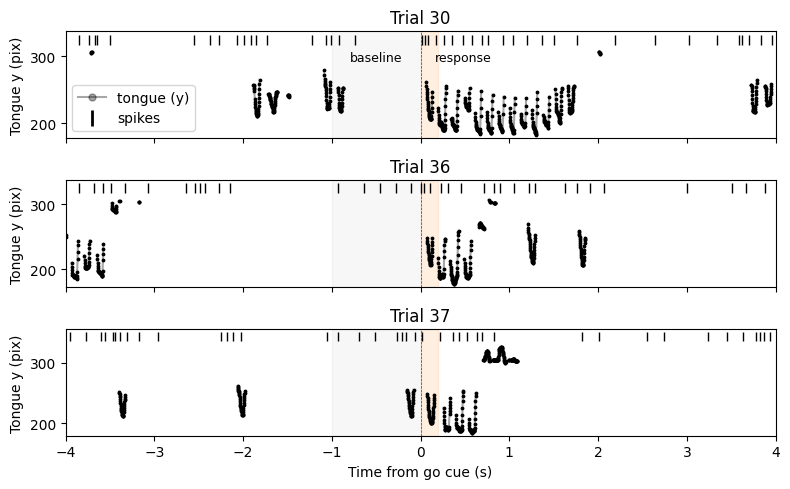

In [10]:
#plotting example trials with spikes and kins

# ---- choose trials to plot ----
trial_list = [30, 36, 37]   # <- change these as desired

go_col = "goCue_start_time_in_session"
win1 = 4.0
win2 = 4.0

fig, axes = plt.subplots(
    len(trial_list), 1,
    figsize=(8, 5),   # shorter height -> visually compressed y
    sharex=True
)

if len(trial_list) == 1:
    axes = [axes]

for ax, n in zip(axes, trial_list):
    # ---- get go cue time ----
    t0 = trials.loc[trials["trial"] == n, go_col].iloc[0]

    # ---- kinematic window ----
    mask_k = (kins["time_in_session"] >= t0 - win1) & (kins["time_in_session"] <= t0 + win2)
    kins_win = kins.loc[mask_k].copy()
    t_rel_k = kins_win["time_in_session"] - t0

    # ---- spike window ----
    spikes_arr = np.asarray(spikes)
    mask_s = (spikes_arr >= t0 - win1) & (spikes_arr <= t0 + win2)
    t_rel_s = spikes_arr[mask_s] - t0

    # ---- tongue signal: connect through NaNs within each movement_id ----
    # (plot each movement as its own line so we don't connect across movements)
    for mid, g in kins_win.groupby("movement_id", sort=False):
        # sort by time just in case
        g = g.sort_values("time_in_session")
        t_rel = g["time_in_session"] - t0

        # keep points for scatter (including NaNs is fine, they'll be skipped)
        ax.scatter(t_rel, g["y"], s=3, color="k", zorder=5)

        # for the line, drop NaNs so the line "bridges" missing detections
        g_line = g.dropna(subset=["y"])
        if len(g_line) >= 2:
            t_line = g_line["time_in_session"] - t0
            ax.plot(t_line, g_line["y"], alpha=0.35, color="k")

    # ---- spike raster above y-range ----
    ymin, ymax = kins_win["y"].min(), kins_win["y"].max()
    spike_y0 = ymax + 10
    spike_y1 = spike_y0 + 15

    for t in t_rel_s:
        ax.vlines(t, spike_y0, spike_y1, color="k", linewidth=1, zorder=10)

    # ---- shaded analysis windows (relative to go cue) ----
    base_a, base_b = cfg.baseline_window_s
    resp_a, resp_b = cfg.count_window_s

    ax.axvspan(base_a, base_b, color="0.75",alpha=0.12, zorder=0)
    ax.axvspan(resp_a, resp_b, color="tab:orange", alpha=0.12, zorder=0)

    # go cue marker
    ax.axvline(0, linestyle="--", color="0.25", linewidth=.5)

    # axis formatting for this subplot
    ax.set_xlim(-win1, win2)
    ax.set_ylim(ymin - 5, spike_y1 + 5)
    ax.set_ylabel("Tongue y (pix)")
    ax.set_title(f"Trial {n}")

# x-label on bottom axis only
axes[-1].set_xlabel("Time from go cue (s)")

# ---- Legend (top-left, only in top subplot) ----
spike_proxy = Line2D([0], [0],
                     linestyle="None",
                     marker="|",
                     color="k",
                     markersize=12,
                     markeredgewidth=2)
                     
tongue_proxy = Line2D([0], [0], color='k', marker='o',
                      markersize=5, linestyle='-', alpha=0.35)

axes[0].legend([tongue_proxy, spike_proxy],
               ["tongue (y)", "spikes"],
               loc="lower left")

# put baseline/response labels at fixed places in the axes
axes[0].text(0.4, 0.82, "baseline", transform=axes[0].transAxes,
        ha="left", va="top", fontsize=9)

axes[0].text(0.52, 0.82, "response", transform=axes[0].transAxes,
        ha="left", va="top", fontsize=9)

plt.tight_layout()

fname = "example_trials_with_kins"   # or build dynamically if you have multiple
png_path = FIG_DIR / f"{fname}.png"
svg_path = FIG_DIR / f"{fname}.svg"

if SAVE_FIG:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(svg_path, dpi=300, bbox_inches="tight")
plt.show()


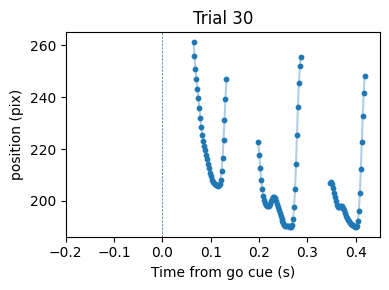

In [11]:
def plot_single_trial(
    trials,
    kins,
    trial_n,
    pre_go=2.0,
    post_go=3.0,
    y_col="y",
    go_col="goCue_start_time_in_session",
):
    # get go cue time
    t0 = trials.loc[trials["trial"] == trial_n, go_col].iloc[0]

    # restrict to window
    mask = (
        (kins["trial"] == trial_n) &
        (kins["time_in_session"] >= t0 - pre_go) &
        (kins["time_in_session"] <= t0 + post_go)
    )

    k = kins.loc[mask]
    t_rel = k["time_in_session"] - t0

    # plot
    plt.figure(figsize=(4, 3))
    plt.plot(t_rel, k[y_col], alpha=0.35)
    plt.scatter(t_rel, k[y_col], s=10)

    plt.axvline(0, linestyle="--", linewidth=0.5)
    plt.xlim(-pre_go, post_go)
    plt.xlabel("Time from go cue (s)")
    plt.ylabel("position (pix)")
    plt.title(f"Trial {trial_n}")
    plt.tight_layout()
    

plot_single_trial(trials, kins, trial_n=30, pre_go=.2, post_go=.45)

fname = "example_trial_zoom_for_reaction_time"   # or build dynamically if you have multiple
png_path = fig_dir / f"{fname}.png"
svg_path = fig_dir / f"{fname}.svg"

if SAVE_FIG:
    fig_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(svg_path, dpi=300, bbox_inches="tight")
plt.show()


In [12]:


# ---------- Analysis ----------
def prepare_df(df_in: pd.DataFrame, x_col: str, y_col: str = "spike_count") -> tuple[pd.DataFrame, str]:
    """Drop NaNs for the chosen predictor and response; return cleaned df and a label."""
    label_map = {
        "reaction_time_firstmove": "first-move RT (s)",
        "reaction_time_cueresponse": "cue-response RT (s)",
        "first_spike_latency": "first-spike latency (s)",
    }
    df = df_in.dropna(subset=[x_col, y_col]).copy()
    return df, label_map.get(x_col, x_col)

def analyze_unit_correlations(df: pd.DataFrame, x_col: str, y_col: str = "spike_count",
                              min_trials: int = 3, alpha: float = 0.05) -> pd.DataFrame:
    rows = []
    for (uid, sess), g in df.groupby(["unit_id", "session"]):
        x = g[x_col].to_numpy()
        y = g[y_col].to_numpy()
        n = len(g)
        if n < min_trials:
            rows.append(
                {
                    "unit_id": uid,
                    "session": sess,
                    "n_trials": n,
                    "spearman_rho": np.nan,
                    "spearman_p": np.nan,
                    "pearson_r": np.nan,
                    "pearson_p": np.nan,
                }
            )
            continue

        rho, ps = spearmanr(x, y, nan_policy="omit")
        if np.nanstd(x) > 0 and np.nanstd(y) > 0:
            r, pp = pearsonr(x, y)
        else:
            r, pp = np.nan, np.nan

        rows.append(
            {
                "unit_id": uid,
                "session": sess,
                "n_trials": n,
                "spearman_rho": float(rho),
                "spearman_p": float(ps),
                "pearson_r": float(r),
                "pearson_p": float(pp),
            }
        )

    out = (
        pd.DataFrame(rows)
        .sort_values(["session", "unit_id"])
        .reset_index(drop=True)
    )

    # --- Add BH-FDR q-values + FDR flags (Spearman + Pearson) ---
    m_s = out["spearman_p"].notna()
    if m_s.any():
        _, q_s, _, _ = multipletests(
            out.loc[m_s, "spearman_p"].values, alpha=alpha, method="fdr_bh"
        )
        out.loc[m_s, "spearman_q"] = q_s
        out["spearman_sig_fdr"] = out["spearman_q"] < alpha
    else:
        out["spearman_q"] = np.nan
        out["spearman_sig_fdr"] = False

    m_p = out["pearson_p"].notna()
    if m_p.any():
        _, q_p, _, _ = multipletests(
            out.loc[m_p, "pearson_p"].values, alpha=alpha, method="fdr_bh"
        )
        out.loc[m_p, "pearson_q"] = q_p
        # separate flag from Spearman
        out["pearson_sig_fdr"] = out["pearson_q"] < alpha
    else:
        out["pearson_q"] = np.nan
        out["pearson_sig_fdr"] = False

    # --- derive t-statistics from correlations and n_trials ---
    def _corr_to_t(r_vec, n_vec):
        r_arr = np.asarray(r_vec, dtype=float)
        n_arr = np.asarray(n_vec, dtype=float)
        t_arr = np.full_like(r_arr, np.nan, dtype=float)

        mask = (
            np.isfinite(r_arr)
            & np.isfinite(n_arr)
            & (n_arr > 2)
            & (np.abs(r_arr) < 0.999999)
        )
        if np.any(mask):
            denom = np.maximum(1.0 - r_arr[mask] ** 2, 1e-12)
            t_arr[mask] = r_arr[mask] * np.sqrt((n_arr[mask] - 2.0) / denom)
        return t_arr

    n = out["n_trials"].to_numpy()

    # Approximate t-statistics for both Spearman rho and Pearson r (df = n-2)
    out["spearman_t"] = _corr_to_t(out["spearman_rho"].to_numpy(), n)
    out["pearson_t"]  = _corr_to_t(out["pearson_r"].to_numpy(),   n)

    return out



def pick_example_units(cor_df: pd.DataFrame, n: int = 3,
                       strategy: str = "top_abs", random_state: int = 0) -> list[tuple]:
    valid = cor_df.dropna(subset=["spearman_rho"])
    if valid.empty:
        return []
    if strategy == "random":
        ex = valid.sample(n=min(n, len(valid)), random_state=random_state)
    elif strategy == "top_neg":
        ex = valid.sort_values("spearman_rho").head(n)
    elif strategy == "top_pos":
        ex = valid.sort_values("spearman_rho", ascending=False).head(n)
    else:  # top_abs
        ex = valid.reindex(valid["spearman_rho"].abs().sort_values(ascending=False).index).head(n)
    return list(zip(ex["unit_id"], ex["session"]))

# ---------- Plotting ----------
def _add_regression_if_possible(ax, x, y, *, xscale="linear", eps=0.0):
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    if xscale == "log":
        # require positive x
        keep = x > 0
        x, y = x[keep], y[keep]
        if x.size < 2 or np.unique(x).size < 2:
            return

        x_fit = np.log10(x)  # or np.log(x); just be consistent
        m, b = np.polyfit(x_fit, y, 1)

        # draw line straight in log-x space
        xx = np.logspace(np.log10(np.min(x)), np.log10(np.max(x)), 200)
        ax.plot(xx, m * np.log10(xx) + b, lw=2)
        return

    # linear case
    if x.size >= 2 and np.unique(x).size >= 2:
        m, b = np.polyfit(x, y, 1)
        xx = np.linspace(np.min(x), np.max(x), 200)
        ax.plot(xx, m * xx + b, lw=2)

# def plot_example_scatter(df: pd.DataFrame, examples: list[tuple], x_col: str, x_label: str,
#                          y_col: str = "spike_count"):
#     if not examples:
#         print("No example units to plot.")
#         return None
#     n = len(examples)
#     fig, axes = plt.subplots(1, n, figsize=(5*n, 4), squeeze=False)
#     for ax, (uid, sess) in zip(axes.ravel(), examples):
#         g = df[(df["unit_id"] == uid) & (df["session"] == sess)]
#         x = g[x_col].to_numpy()
#         y = g[y_col].to_numpy()
#         ax.scatter(x, y, s=20, alpha=0.15)
#         _add_regression_if_possible(ax, x, y)
#         ax.grid(True, ls=":", alpha=0.5)
#         ax.set_title(f"{uid} ({sess}) • n={len(g)}")
#         ax.set_xlabel(f"{x_label}")
#         ax.set_ylabel(f"{y_col.replace('_',' ')}")
#     fig.suptitle(f"Examples: {y_col} vs {x_label}", y=1.02)
#     plt.tight_layout()
#     return fig

def plot_example_scatter(
    df: pd.DataFrame,
    examples: list[tuple],
    x_col: str,
    x_label: str,
    y_col: str = "spike_count",
    *,
    jitter_x: Union[float, str] = "auto",
    jitter_y: Union[float, str] = "auto",
    jitter_seed: int = 0,
):
    """
    Scatter example units with optional jitter.

    Parameters
    ----------
    jitter_x, jitter_y : float
        Standard deviation of Gaussian jitter applied to axis values.
        Set to 0 to disable.
        For count variables, values around 0.2–0.4 usually work well.
    jitter_seed : int
        RNG seed for reproducibility.
    """

    if not examples:
        print("No example units to plot.")
        return None

    rng = np.random.default_rng(jitter_seed)

    n = len(examples)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4), squeeze=False)

    for ax, (uid, sess) in zip(axes.ravel(), examples):
        g = df[(df["unit_id"] == uid) & (df["session"] == sess)]

        x = g[x_col].to_numpy()
        y = g[y_col].to_numpy()

        # # --- jitter only for plotting ---
        x_plot = x.copy()
        y_plot = y.copy()

        # --- auto detect integer-ish ---
        jy = jitter_y
        if jy == "auto":
            if np.all(np.isclose(y, np.round(y), atol=1e-6)):
                jy = 0.2
            else:
                jy = 0.0

        jx = jitter_x
        if jx == "auto":
            if np.all(np.isclose(x, np.round(x), atol=1e-6)):
                jx = 0.2
            else:
                jx = 0.0

        if isinstance(jx, (int, float)) and jx > 0:
            x_plot = x_plot + rng.normal(0, jx, size=len(x_plot))

        if isinstance(jy, (int, float)) and jy > 0:
            y_plot = y_plot + rng.normal(0, jy, size=len(y_plot))


        # --- scatter ---
        ax.scatter(x_plot, y_plot, s=20, alpha=0.2, edgecolors="none")

        # --- regression uses true values ---
        _add_regression_if_possible(ax, x, y)

        ax.grid(True, ls=":", alpha=0.5)
        ax.set_title(f"{uid} ({sess}) • n={len(g)}")
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_col.replace("_", " "))

    fig.suptitle(f"Examples: {y_col} vs {x_label}", y=1.02)
    plt.tight_layout()

    return fig


def plot_example_scatter(
    df: pd.DataFrame,
    examples: list[tuple],
    x_col: str,
    x_label: str,
    y_col: str = "spike_count",
    *,
    jitter_x: Union[float, str] = "auto",
    jitter_y: Union[float, str] = "auto",
    jitter_seed: int = 0,
    xscale: str = "linear",   
):
    """
    Scatter example units with optional jitter.
    """

    if not examples:
        print("No example units to plot.")
        return None

    rng = np.random.default_rng(jitter_seed)

    n = len(examples)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4), squeeze=False)

    for ax, (uid, sess) in zip(axes.ravel(), examples):
        g = df[(df["unit_id"] == uid) & (df["session"] == sess)]

        x = g[x_col].to_numpy()
        y = g[y_col].to_numpy()

        # --- if log scale, remove non-positive values ---
        if xscale == "log":
            keep = x > 0
            x = x[keep]
            y = y[keep]

        x_plot = x.copy()
        y_plot = y.copy()

        # --- auto detect integer-ish ---
        jy = jitter_y
        if jy == "auto":
            jy = 0.2 if np.all(np.isclose(y, np.round(y), atol=1e-6)) else 0.0

        jx = jitter_x
        if jx == "auto":
            jx = 0.2 if np.all(np.isclose(x, np.round(x), atol=1e-6)) else 0.0

        if isinstance(jx, (int, float)) and jx > 0:
            x_plot = x_plot + rng.normal(0, jx, size=len(x_plot))

        if isinstance(jy, (int, float)) and jy > 0:
            y_plot = y_plot + rng.normal(0, jy, size=len(y_plot))

        ax.scatter(x_plot, y_plot, s=20, alpha=0.2, edgecolors="none")

        _add_regression_if_possible(ax, x, y, xscale=xscale)

        ax.set_xscale(xscale)  

        ax.grid(True, ls=":", alpha=0.5)
        ax.set_title(f"{uid} ({sess}) • n={len(x)}")
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_col.replace("_", " "))

    fig.suptitle(f"Examples: {y_col} vs {x_label}", y=1.02)
    plt.tight_layout()

    return fig

def plot_summary_distribution(
    cor_df: pd.DataFrame,
    alpha: float = 0.05,
    x_label: str = "",
    y_label: str = "spike_count",
    volcano_uses_q: bool = True,  # kept for backward compatibility (unused)
    metric: str = "rho",
):
    """
    Single-panel summary plot: histogram of per-unit effect sizes,
    colored by significance.

    metric options (case-insensitive):

      - "rho" or "spearman_rho"  -> Spearman rho
      - "pearson_rho" or "pearson" -> Pearson r
      - "t" or "pearson_t"       -> Pearson t-statistic
      - "spearman_t"             -> Spearman t-statistic

    This keeps 'metric="rho"' and 'metric="t"' behavior logically
    compatible with the previous function, but uses a simpler
    one-panel visualization (the old middle panel).
    """
    m = metric.lower()

    if m in ("rho", "spearman_rho"):
        effect_col = "spearman_rho"
        p_col = "spearman_p"
        q_col = "spearman_q"
        effect_label = "Spearman ρ"
    elif m in ("pearson_rho", "pearson"):
        effect_col = "pearson_r"
        p_col = "pearson_p"
        q_col = "pearson_q"
        effect_label = "Pearson r"
    elif m in ("t", "pearson_t"):
        effect_col = "pearson_t"
        p_col = "pearson_p"
        q_col = "pearson_q"
        effect_label = "Pearson t-statistic"
    elif m in ("spearman_t",):
        effect_col = "spearman_t"
        p_col = "spearman_p"
        q_col = "spearman_q"
        effect_label = "Spearman t-statistic"
    else:
        raise ValueError(
            "Unknown metric '%s'. Expected one of: "
            "'rho', 'spearman_rho', 'pearson_rho', 'pearson', "
            "'t', 'pearson_t', 'spearman_t'." % metric
        )

    if effect_col not in cor_df.columns:
        print("No column '%s' in cor_df; nothing to plot for metric='%s'." % (effect_col, metric))
        return None

    # Drop rows with missing effect value
    valid = cor_df.dropna(subset=[effect_col]).copy()
    if valid.empty:
        print("No valid %s values to summarize." % effect_label)
        return None

    # Determine significance from q (preferred) or p
    have_q = (q_col in valid.columns) and valid[q_col].notna().any()
    if have_q:
        sig_mask = valid[q_col] < alpha
        sig_label = "sig (FDR)"
        nonsig_label = "not sig (FDR)"
    else:
        if p_col not in valid.columns:
            sig_mask = np.zeros(len(valid), dtype=bool)
            sig_label = "sig"
            nonsig_label = "not sig"
        else:
            sig_mask = valid[p_col] < alpha
            sig_label = "sig (p < %.3g)" % alpha
            nonsig_label = "not sig"

    vals = valid[effect_col].to_numpy()
    sig_vals = vals[sig_mask.to_numpy()]
    nonsig_vals = vals[~sig_mask.to_numpy()]

    fig, ax = plt.subplots(figsize=(5.5, 4))

    # Common bin edges so sig/nonsig histograms align
    bin_edges = np.histogram_bin_edges(vals, bins=20)

    # Build datasets & labels; stacked=True makes bar heights sum to total per bin
    datasets = [nonsig_vals, sig_vals]
    labels   = [nonsig_label, sig_label]

    ax.hist(
        datasets,
        bins=bin_edges,
        stacked=True,
        alpha=0.9,
        label=labels,
    )


    # Zero reference: meaningful for both corr and t
    ax.axvline(0.0, ls="--", lw=1)

    ax.set_xlabel(effect_label)
    ax.set_ylabel("Units")
    ax.grid(True, axis="y", ls=":", alpha=0.5)

    n_units = len(valid)
    n_sig = int(sig_mask.sum())
    ax.set_title(
        "%s vs %s\n%s (n=%d, sig=%d, α=%.3g)"
        % (y_label, x_label, effect_label, n_units, n_sig, alpha)
    )
    ax.legend(frameon=False, fontsize=8)

    # ---- enforce symmetric x-limits ----
    abs_max = np.nanmax(np.abs(vals))
    if np.isfinite(abs_max) and abs_max > 0:
        lim = abs_max * 1.05
        ax.set_xlim(-lim, lim)
    fig.tight_layout()
    return fig



def plot_summary_panels(
    cor_df: pd.DataFrame,
    alpha: float = 0.05,
    x_label: str = "",
    y_label: str = "spike_count",
    volcano_uses_q: bool = True,
    metric: str = "rho",  # NEW: "rho" (Spearman) or "t" (Pearson-derived t-stat)
):
    """
    Summary plots across units.

    metric:
        "rho" -> use Spearman ρ (existing behavior)
        "t"   -> use Pearson-derived t-statistics (column 'pearson_t')
    """
    # --- NEW: choose which effect size + stats to use ---
    if metric == "rho":
        effect_col = "spearman_rho"
        p_col = "spearman_p"
        q_col = "spearman_q"
        effect_label = "Spearman ρ"
    elif metric == "t":
        effect_col = "pearson_t"
        p_col = "pearson_p"
        q_col = "pearson_q"
        effect_label = "t-statistic (from Pearson r)"
    else:
        raise ValueError(f"Unknown metric '{metric}', expected 'rho' or 't'.")

    if effect_col not in cor_df.columns:
        print(f"No column '{effect_col}' in cor_df; nothing to plot for metric='{metric}'.")
        return None

    # require chosen effect_col; allow p/q to be missing but try to use q first
    valid = cor_df.dropna(subset=[effect_col]).copy()
    if valid.empty:
        print(f"No valid {effect_label} values to summarize.")
        return None

    have_q = (q_col in valid.columns) and valid[q_col].notna().any()
    # significance mask for counts + coloring (within valid)
    if have_q:
        sig_series = valid[q_col] < alpha
    else:
        sig_series = valid[p_col] < alpha

    n_units = len(valid)
    vals = valid[effect_col].to_numpy()
    pos_sig = int(((vals > 0) & sig_series.to_numpy()).sum())
    neg_sig = int(((vals < 0) & sig_series.to_numpy()).sum())

    # Volcano data
    if have_q and volcano_uses_q:
        finite = valid[q_col] > 0
        x_volc = valid.loc[finite, effect_col].to_numpy()
        y_volc = -np.log10(valid.loc[finite, q_col].to_numpy())
        sig_volc = (valid.loc[finite, q_col] < alpha).to_numpy()
        ylab_volc = "-log10(q)"
    else:
        finite = valid[p_col] > 0
        x_volc = valid.loc[finite, effect_col].to_numpy()
        y_volc = -np.log10(valid.loc[finite, p_col].to_numpy())
        sig_volc = (valid.loc[finite, p_col] < alpha).to_numpy()
        ylab_volc = "-log10(p)"
    pthr_y = -np.log10(alpha)

    # Sorted for lollipop
    vs = valid.sort_values(effect_col).reset_index(drop=True)
    ypos = np.arange(len(vs))
    if have_q:
        is_sig_sorted = (vs[q_col] < alpha).to_numpy()
    else:
        is_sig_sorted = (vs[p_col] < alpha).to_numpy()

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))

    # (1) Lollipop
    ax = axes[0]
    eff_vals_sorted = vs[effect_col].to_numpy()
    for i, v in enumerate(eff_vals_sorted):
        ax.hlines(i, 0, v, linewidth=1.0, alpha=0.7)
    ax.plot(
        eff_vals_sorted[~is_sig_sorted],
        ypos[~is_sig_sorted],
        "o",
        ms=4,
        alpha=0.8,
        label="not sig (FDR)",
    )
    ax.plot(
        eff_vals_sorted[is_sig_sorted],
        ypos[is_sig_sorted],
        "o",
        ms=4,
        alpha=0.9,
        color="orange",
        label="sig (FDR)",
    )
    ax.axvline(0, ls="--", lw=1)
    ax.set_yticks([])
    ax.set_xlabel(effect_label)
    ax.set_title(f"Per-unit {effect_label} (sorted)")
    ax.grid(True, axis="x", ls=":", alpha=0.5)

    # (2) Histogram colored by FDR
    ax = axes[1]
    bins = np.histogram_bin_edges(vals, bins=20)
    hist, edges = np.histogram(vals, bins=bins)
    hist_sig, _ = np.histogram(valid.loc[sig_series, effect_col], bins=bins)
    widths = np.diff(edges)
    ax.bar(
        edges[:-1],
        hist - hist_sig,
        width=widths,
        align="edge",
        alpha=0.7,
        label="not sig (FDR)",
    )
    ax.bar(
        edges[:-1],
        hist_sig,
        width=widths,
        align="edge",
        alpha=0.9,
        color="orange",
        label="sig (FDR)",
    )
    ax.axvline(0, ls="--", lw=1)
    val_max = np.max(np.abs(vals))
    ax.set_xlim(-val_max * 1.2, val_max * 1.2)
    ax.set_xlabel(effect_label)
    ax.set_ylabel("Units")
    ax.set_title(f"Distribution of {effect_label} (FDR coloring)")
    ax.grid(True, axis="y", ls=":", alpha=0.5)
    ax.legend(frameon=False, fontsize=8)

    # (3) Volcano
    ax = axes[2]
    ax.scatter(
        x_volc[~sig_volc],
        y_volc[~sig_volc],
        s=16,
        alpha=0.7,
        label="not sig (FDR)",
    )
    ax.scatter(
        x_volc[sig_volc],
        y_volc[sig_volc],
        s=16,
        alpha=0.9,
        color="orange",
        label="sig (FDR)",
    )
    ax.axhline(pthr_y, ls="--", lw=1)
    ax.set_xlabel(effect_label)
    ax.set_ylabel(ylab_volc)
    ax.set_title(f"{effect_label} vs significance (FDR)")
    ax.legend(frameon=False, fontsize=8)
    ax.grid(True, ls=":", alpha=0.5)

    fig.suptitle(
        f"{y_label} vs {x_label}  "
        f"({effect_label}, n={n_units}, FDR sig: pos={pos_sig}, neg={neg_sig}, α={alpha})",
        y=1.02,
    )
    plt.tight_layout()
    return fig


# ---------- Printed stats ----------
def print_summary_tests(cor_df: pd.DataFrame, alpha: float = 0.05):
    df = cor_df.copy()

    # Population-level tests (unchanged)
    sdf = df.dropna(subset=["spearman_rho"]).query("n_trials >= 3")
    rho = sdf["spearman_rho"].to_numpy()
    if len(rho) >= 3 and np.any(rho != 0):
        W, p_wil = wilcoxon(rho, alternative="two-sided", zero_method="wilcox")
        print(f"[Spearman ρ] Wilcoxon vs 0: W={W:.1f}, p={p_wil:.3g}, median={np.nanmedian(rho):.3f}, n_units={len(rho)}")
    else:
        print("[Spearman ρ] Not enough nonzero data for Wilcoxon.")

    neg = int(np.sum(rho < 0)); pos = int(np.sum(rho > 0))
    n_nonzero = neg + pos
    if n_nonzero > 0:
        p_sign = binomtest(neg, n_nonzero, 0.5, alternative="two-sided").pvalue
        print(f"[Spearman ρ] Sign test: negatives={neg}, positives={pos}, p={p_sign:.3g}, n_units={n_nonzero}")
    else:
        print("[Spearman ρ] No nonzero correlations for sign test.")

    pdf = df.dropna(subset=["pearson_r"]).query("n_trials >= 4")
    if not pdf.empty:
        r = np.clip(pdf["pearson_r"].to_numpy(), -0.999999, 0.999999)
        w = np.maximum(pdf["n_trials"].to_numpy() - 3, 1e-6)
        z = np.arctanh(r); z_bar = np.sum(w * z) / np.sum(w)
        se = 1.0 / np.sqrt(np.sum(w)); z_stat = z_bar / se
        from scipy.stats import norm
        p_meta = 2 * (1 - norm.cdf(abs(z_stat))); r_meta = np.tanh(z_bar)
        r_lo = np.tanh(z_bar - 1.96 * se); r_hi = np.tanh(z_bar + 1.96 * se)
        print(f"[Pearson r] Fisher-z meta: r_meta={r_meta:.3f} (95% CI {r_lo:.3f}..{r_hi:.3f}), z={z_stat:.2f}, p={p_meta:.3g}, n_units={len(pdf)}")
    else:
        print("[Pearson r] Not enough data for Fisher-z meta-analysis.")

    # FDR counts
    if "spearman_q" in df and df["spearman_q"].notna().any():
        sig = df["spearman_q"] < alpha
        pos_sig = int(((df["spearman_rho"] > 0) & sig).sum())
        neg_sig = int(((df["spearman_rho"] < 0) & sig).sum())
        print(f"[Per-unit FDR @ α={alpha}] sig units: total={int(sig.sum())}, pos={pos_sig}, neg={neg_sig}")
    else:
        print("[Per-unit FDR] No q-values present; ensure analyze_unit_correlations() added them.")


# ---------- Convenience runner for ANY predictor ----------
def run_and_plot_for_predictor(
    df_in: pd.DataFrame,
    x_col: str,
    *,
    y_col: str = "spike_count",
    example_n: int = 3,
    alpha: float = 0.05,
    filter_query=None,
    summary_metric: str = "rho",
):
    """Full pipeline for a given predictor column."""
    df0 = df_in.query(filter_query).copy() if filter_query else df_in
    df, x_label = prepare_df(df0, x_col=x_col, y_col=y_col)

    # pass alpha through so FDR in analyze_unit_correlations matches what you pass in
    cor_df = analyze_unit_correlations(
        df,
        x_col=x_col,
        y_col=y_col,
        min_trials=50,
        alpha=alpha,
    )

    examples = pick_example_units(
        cor_df,
        n=example_n,
        strategy="top_abs",
        random_state=0,
    )
    fig_examples = plot_example_scatter(
        df,
        examples,
        x_col=x_col,
        x_label=x_label,
        y_col=y_col,
    )

    # fig_summary = plot_summary_panels(
    #     cor_df,
    #     alpha=alpha,
    #     x_label=x_label,
    #     y_label=y_col,
    #     metric=summary_metric,
    # )

    fig_summary = plot_summary_distribution(
        cor_df,
        alpha=alpha,
        x_label=x_label,
        y_label=y_col,
        metric=summary_metric,
    )

    print_summary_tests(cor_df, alpha=alpha)
    return {
        "df": df,
        "cor_df": cor_df,
        "fig_examples": fig_examples,
        "fig_summary": fig_summary,
    }



No example units to plot.
[Spearman ρ] Wilcoxon vs 0: W=2558.0, p=0.693, median=0.002, n_units=103
[Spearman ρ] Sign test: negatives=50, positives=53, p=0.844, n_units=103
[Pearson r] Fisher-z meta: r_meta=0.036 (95% CI 0.025..0.047), z=6.33, p=2.48e-10, n_units=103
[Per-unit FDR @ α=0.05] sig units: total=32, pos=20, neg=12


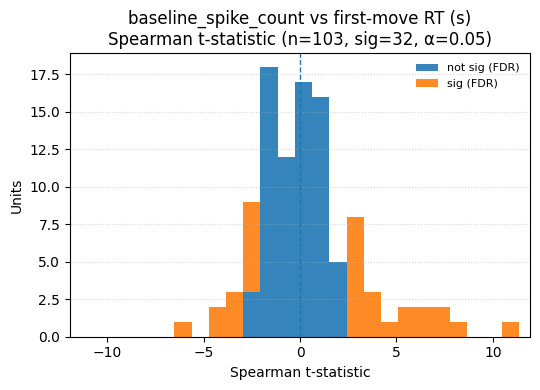

In [13]:
spkct_rt_bl = run_and_plot_for_predictor(
    all_counts_df,
    x_col="reaction_time_firstmove",
    y_col="baseline_spike_count",
    example_n=0,
    alpha=0.05,
    filter_query="reaction_time_firstmove < 2",
    summary_metric='spearman_t'
)

if SAVE_FIG:
    FIG_DIR.mkdir(parents=True, exist_ok=True)

    spkct_rt_bl["fig_summary"].savefig(FIG_DIR / "spkct_rt_bl.png", dpi=300, bbox_inches="tight")
    spkct_rt_bl["fig_summary"].savefig(FIG_DIR / "spkct_rt_bl.svg", dpi=300, bbox_inches="tight")

No example units to plot.
[Spearman ρ] Wilcoxon vs 0: W=2394.0, p=0.35, median=0.004, n_units=103
[Spearman ρ] Sign test: negatives=51, positives=52, p=1, n_units=103
[Pearson r] Fisher-z meta: r_meta=-0.011 (95% CI -0.022..-0.000), z=-2.00, p=0.045, n_units=103
[Per-unit FDR @ α=0.05] sig units: total=37, pos=22, neg=15


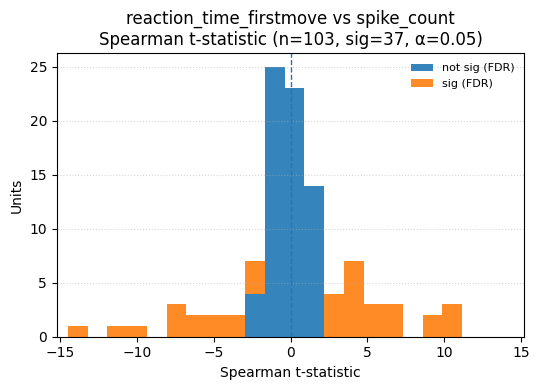

In [14]:
spkct_rt = run_and_plot_for_predictor(
    all_counts_df,
    x_col="spike_count",
    y_col="reaction_time_firstmove",
    example_n=0,
    alpha=0.05,
    filter_query="reaction_time_firstmove < 2",
    summary_metric='spearman_t'
)

if SAVE_FIG:
    FIG_DIR.mkdir(parents=True, exist_ok=True)

    spkct_rt["fig_summary"].savefig(FIG_DIR / "spkct_rt.png", dpi=300, bbox_inches="tight")
    spkct_rt["fig_summary"].savefig(FIG_DIR / "spkct_rt.svg", dpi=300, bbox_inches="tight")

In [15]:
examples = pick_example_units(spkct_rt["cor_df"], n=20, strategy="top_neg", random_state=0)
examples

[(22.0, 'behavior_751004_2024-12-21_13-28-28'),
 (145.0, 'behavior_751004_2024-12-23_14-20-03'),
 (193.0, 'behavior_751004_2024-12-21_13-28-28'),
 (649.0, 'behavior_784806_2025-06-20_13-39-16'),
 (6.0, 'behavior_751004_2024-12-21_13-28-28'),
 (146.0, 'behavior_751004_2024-12-23_14-20-03'),
 (72.0, 'behavior_784806_2025-06-20_13-39-16'),
 (263.0, 'behavior_751004_2024-12-20_13-26-11'),
 (123.0, 'behavior_751004_2024-12-22_13-09-17'),
 (268.0, 'behavior_751004_2024-12-20_13-26-11'),
 (16.0, 'behavior_754897_2025-03-14_11-28-53'),
 (28.0, 'behavior_751181_2025-02-27_11-24-47'),
 (45.0, 'behavior_763590_2025-05-01_10-59-18'),
 (29.0, 'behavior_751181_2025-02-25_12-12-35'),
 (87.0, 'behavior_716325_2024-05-31_10-31-14'),
 (89.0, 'behavior_784806_2025-06-20_13-39-16'),
 (13.0, 'behavior_751181_2025-02-27_11-24-47'),
 (14.0, 'behavior_763590_2025-05-01_10-59-18'),
 (144.0, 'behavior_751766_2025-02-13_11-31-21'),
 (56.0, 'behavior_791691_2025-06-27_13-54-30')]

,n_trials,spearman_rho,spearman_p,spearman_q,spearman_sig_fdr,pearson_r,pearson_p,pearson_q,pearson_sig_fdr
7,510,-0.541132,3.921965e-40,4.039624e-38,True,-0.364613,1.761014e-17,9.069222e-16,True


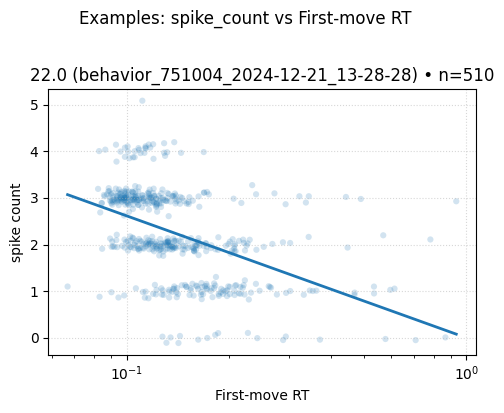

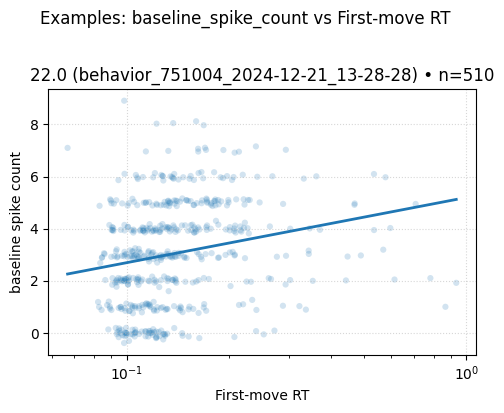

In [16]:
# unit_num = 649
# session_str = 'behavior_784806_2025-06-20_13-39-16'

# examples = [(unit_num, session_str)]

example = examples[0]

session_str = example[1]
unit_num = example[0]  

cor_row = spkct_rt["cor_df"].query(
    "session == @session_str and unit_id == @unit_num"
)

display(cor_row[[
    "n_trials", "spearman_rho", "spearman_p",
    "spearman_q", "spearman_sig_fdr",
    "pearson_r", "pearson_p", "pearson_q", "pearson_sig_fdr"
]])


fig = plot_example_scatter(
    df=spkct_rt["df"],
    examples=[examples[0]],
    x_col="reaction_time_firstmove",
    x_label="First-move RT",
    y_col="spike_count",
    xscale="log",
    jitter_y=0.1,
)
if SAVE_FIG and fig is not None:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIG_DIR / "example_unit_spkct_vs_rt.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIG_DIR / "example_unit_spkct_vs_rt.svg", dpi=300, bbox_inches="tight")    
plt.show()


fig = plot_example_scatter(
    df=spkct_rt_bl["df"],
    examples=[examples[0]],
    x_col="reaction_time_firstmove",
    x_label="First-move RT",
    y_col="baseline_spike_count",
    xscale="log",
    jitter_y=0.1,
)
if SAVE_FIG and fig is not None:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIG_DIR / "example_unit_spkct_vs_rt_bl.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIG_DIR / "example_unit_spkct_vs_rt_bl.svg", dpi=300, bbox_inches="tight")    
plt.show()

In [17]:
#data org for spatial plots

def _get_cor_df(cor_source):
    """Accept dict like spkct_rt (with key 'cor_df') or a raw DataFrame."""
    if isinstance(cor_source, dict):
        if "cor_df" not in cor_source:
            raise KeyError("cor_source dict must contain key 'cor_df'")
        return cor_source["cor_df"]
    return cor_source

def add_correlations(
    features_df,
    cor_source,
    *,
    prefix,
    session_col="session",
    unit_col_features="unit",
    unit_col_cor="unit_id",
    keep_cols=None,
    # if keep_cols=None, we take all non-key columns from cor_df
    validate="one_to_one",
    overwrite=False,
):
    """
    Idempotently add ONE correlation table into features_df using namespaced columns.

    - prefix: e.g. "rt" or "rt_bl" (becomes "<prefix>__<colname>")
    - overwrite=False: if columns already exist, keep existing and do nothing
    """
    feats = features_df.copy()
    cor_df = _get_cor_df(cor_source).copy()

    # normalize key colnames
    if unit_col_cor != unit_col_features:
        cor_df = cor_df.rename(columns={unit_col_cor: unit_col_features})

    keys = [session_col, unit_col_features]

    if keep_cols is None:
        keep_cols = [c for c in cor_df.columns if c not in keys]

    # build namespaced correlation frame: only keys + selected cols, renamed with prefix
    rename_map = {c: f"{prefix}__{c}" for c in keep_cols}
    cor_small = cor_df[keys + keep_cols].rename(columns=rename_map)

    # idempotency check
    target_cols = list(rename_map.values())
    already_present = all(c in feats.columns for c in target_cols)
    if already_present and not overwrite:
        print('columns already present in feats')
        return feats  # no-op

    # if some columns exist and overwrite=False, avoid duplicating by merging only missing cols
    if not overwrite:
        missing = [c for c in target_cols if c not in feats.columns]
        if len(missing) == 0:
            return feats
        # map back to original cols to subset cor_small
        cor_small = cor_small[keys + missing]

    # merge
    feats = feats.merge(cor_small, on=keys, how="left", validate=validate)

    # (optional) add abs convenience columns if spearman_t exists under this prefix
    tcol = f"{prefix}__spearman_t"
    if tcol in feats.columns:
        abscol = f"{prefix}__spearman_t_abs"
        if abscol not in feats.columns or overwrite:
            feats[abscol] = feats[tcol].abs()

    return feats

def list_corr_prefixes(features_df, *, separator="__"):
    """Quick helper: see what prefixes exist in your wide table."""
    prefixes = set()
    for c in features_df.columns:
        if separator in c:
            prefixes.add(c.split(separator, 1)[0])
    return sorted(prefixes)


# base table: ephys coords + unit metadata
features_combined = filtered_ephys.copy()

# add two correlation sources into the same table
features_combined = add_correlations(features_combined, spkct_rt,    prefix="rt")
features_combined = add_correlations(features_combined, spkct_rt_bl, prefix="rt_bl")


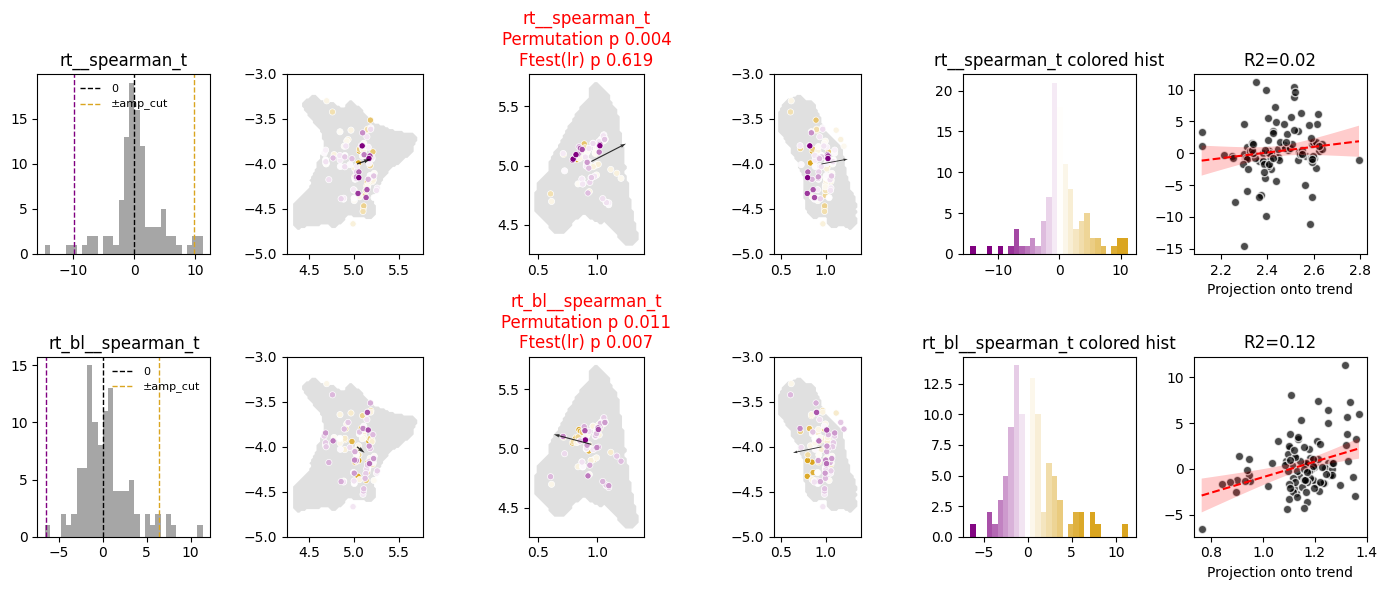

In [18]:
# import os
# import pickle
# import numpy as np
# import matplotlib.pyplot as plt

# from matplotlib.colors import Normalize, LinearSegmentedColormap
# from sklearn.linear_model import LinearRegression
# from scipy import stats
# from statsmodels.stats.multitest import multipletests
# from trimesh import load_mesh
# from ccf_utils import pir_to_lps, project_to_plane

MESH_PATH = "/root/capsule/data/LC-NE_scratch_data_1/combined/ccf_maps/20250418_transformed_remesh_10_ccf25.obj"

def spatial_dependence_summary(
    coords,
    values,
    *,
    k_neighbors=15,
    n_splits=5,
    permutations=5000,
    seed=0,
    return_null=False,
):
    """
    Combines:
      (1) Linear trend test: value ~ x + y + z (PERMUTATION test; permute values, keep coords fixed)
      (2) 5-fold CV predictability with kNN (distance-weighted) + permutation p-value

    Returns a dictionary of results.
    """
    import numpy as np
    import statsmodels.api as sm
    from sklearn.model_selection import KFold
    from sklearn.neighbors import KNeighborsRegressor
    from sklearn.metrics import r2_score

    rng = np.random.default_rng(seed)

    X = np.asarray(coords, float)
    y = np.asarray(values, float)

    # drop NaNs / infs; reshape X to N x D
    X = X.reshape(X.shape[0], -1)
    ok = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    X = X[ok]
    y = y[ok]
    n = y.size
    if n < 10:
        raise ValueError(f"Too few valid points after filtering (n={n}).")

    # -------------------------
    # (1) Linear regression trend (PERMUTATION p-value)
    # -------------------------
    X_const = sm.add_constant(X)  # [1, x, y, z] (or [1, ...D dims])

    model_full = sm.OLS(y, X_const).fit()
    r2_obs = float(model_full.rsquared)

    # Deterministic per-permutation seeds (same pattern you used below)
    perm_seeds = np.random.SeedSequence(seed + 12345).spawn(permutations)
    perm_seeds_uint = np.array(
        [s.generate_state(1, dtype=np.uint32)[0] for s in perm_seeds],
        dtype=np.uint32
    )

    def _one_perm_r2_linear(s_uint):
        r = np.random.default_rng(int(s_uint))
        y_perm = r.permutation(y)
        return sm.OLS(y_perm, X_const).fit().rsquared

    # compute permutation null (parallel if possible)
    try:
        from joblib import Parallel, delayed
        r2_perm = np.asarray(
            Parallel(n_jobs=-1, prefer="processes")(
                delayed(_one_perm_r2_linear)(s_uint) for s_uint in perm_seeds_uint
            ),
            dtype=float,
        )
    except Exception:
        r2_perm = np.empty(permutations, float)
        for i, s_uint in enumerate(perm_seeds_uint):
            r2_perm[i] = _one_perm_r2_linear(s_uint)

    # one-sided permutation p-value (greater-than)
    p_trend_perm = (np.sum(r2_perm >= r2_obs) + 1) / (permutations + 1)

    # (Optional) also report the classic F-stat if you still want it (no p-value)
    # This is just for interpretability; p-value comes from permutations.
    # F = ( (SSE_null - SSE_full)/df1 ) / ( SSE_full/df2 )
    y_mean = y.mean()
    sse_null = np.sum((y - y_mean) ** 2)
    sse_full = np.sum(model_full.resid ** 2)
    df1 = X_const.shape[1] - 1
    df2 = n - X_const.shape[1]
    f_stat = ((sse_null - sse_full) / df1) / (sse_full / df2) if df2 > 0 else np.nan

    # -------------------------
    # (2) CV predictability (kNN) + permutation test (parallel)
    # -------------------------
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    def cv_r2(y_target):
        preds = np.zeros_like(y_target)
        for tr, te in kf.split(X):
            model = KNeighborsRegressor(
                n_neighbors=min(k_neighbors, len(tr)),
                weights="distance",
            )
            model.fit(X[tr], y_target[tr])
            preds[te] = model.predict(X[te])
        return r2_score(y_target, preds)

    r2_cv_obs = cv_r2(y)

    perm_seeds = np.random.SeedSequence(seed).spawn(permutations)
    perm_seeds_uint = np.array([s.generate_state(1, dtype=np.uint32)[0] for s in perm_seeds], dtype=np.uint32)

    def _one_perm_r2_knn(s_uint):
        r = np.random.default_rng(int(s_uint))
        return cv_r2(r.permutation(y))

    try:
        from joblib import Parallel, delayed
        r2_cv_perm = np.asarray(
            Parallel(n_jobs=-1, prefer="processes")(
                delayed(_one_perm_r2_knn)(s_uint) for s_uint in perm_seeds_uint
            ),
            dtype=float,
        )
    except Exception:
        r2_cv_perm = np.empty(permutations, float)
        for i, s_uint in enumerate(perm_seeds_uint):
            r2_cv_perm[i] = _one_perm_r2_knn(s_uint)

    p_cv = (np.sum(r2_cv_perm >= r2_cv_obs) + 1) / (permutations + 1)

    out = {
        "n_used": int(n),
        "inputs": {
            "k_neighbors": int(k_neighbors),
            "n_splits": int(n_splits),
            "permutations": int(permutations),
            "seed": int(seed),
        },
        "linear_trend": {
            "coef_const_x_y_z": model_full.params.tolist(),  # [const, b1..bD]
            "r2": float(r2_obs),
            "F_stat": float(f_stat),
            "p_value_permutation_r2": float(p_trend_perm),
            "null_mean_r2": float(np.mean(r2_perm)),
            "null_std_r2": float(np.std(r2_perm, ddof=1)),
        },
        "cv_predictability_knn": {
            "r2_cv": float(r2_cv_obs),
            "p_value_permutation": float(p_cv),
            "null_mean": float(np.mean(r2_cv_perm)),
            "null_std": float(np.std(r2_cv_perm, ddof=1)),
        },
    }

    if return_null:
        out["linear_trend"]["r2_null_distribution"] = r2_perm.tolist()
        out["cv_predictability_knn"]["r2_null_distribution"] = r2_cv_perm.tolist()

    return out

# ----------------------------
# 0) Geometry + CCF coords (same as your cell)
# ----------------------------
ml, ap, dv = 0, 1, 2
planes = {'sag': [ap, dv], 'hor': [ml, ap], 'cor': [ml, dv]}

norm = Normalize(vmin=0, vmax=1)

mesh = load_mesh(MESH_PATH)
mesh_vertices = np.array(mesh.vertices, dtype=float)
mesh_vertices = (mesh_vertices - np.array([216, 18, 228], dtype=float)) * 25 / 1000.0
mesh_vertices_lps = pir_to_lps(mesh_vertices)
mesh_vertices_mm = mesh_vertices_lps

# --- 3D anatomical points ---
ccfs = features_combined[['x_ccf', 'y_ccf', 'z_ccf']].values.astype(float)
bregma_LPS_mm = np.array([-5.7, 5.4, -0.45], dtype=float)
ccfs = ccfs - bregma_LPS_mm
ccfs[:, ml] = np.abs(ccfs[:, ml])  # mirror ML to left hemisphere

mesh_contours = {
    plane_name: project_to_plane(mesh_vertices_mm, plane_axes, pitch=0.02, margin=0.5)
    for plane_name, plane_axes in planes.items()
}

# ----------------------------
# 1) Feature map for RT T-stats (color -> white -> color)
# ----------------------------
rt_colors = LinearSegmentedColormap.from_list(
    'rt_t',
    [(0.0, 'purple'), (0.5, 'white'), (1.0, 'goldenrod')]
)
rt_bl_colors = LinearSegmentedColormap.from_list(
    'rt_bl_t',
    [(0.0, 'purple'), (0.5, 'white'), (1.0, 'goldenrod')]
)

feature_map = {
    'rt__spearman_t': rt_colors,
    'rt_bl__spearman_t': rt_bl_colors,
}

# ----------------------------
# 2) Spatial dependence analysis for these RT features (so arrows + pvals exist)
# ----------------------------
# mask = (features_combined['selected'].values > 0)  # same as your plotting mask
mask = np.ones(len(features_combined), dtype=bool)
spatial_dependence_results = {}

for feature_name in feature_map.keys():
    values = features_combined[feature_name].values.astype(float)
    result = spatial_dependence_summary(
        ccfs[mask, :],
        values[mask],
        k_neighbors=30,
        n_splits=5,
        permutations=2000,
        seed=42,
    )
    spatial_dependence_results[feature_name] = result

# FDR for knn
p_values = [spatial_dependence_results[f]['cv_predictability_knn']['p_value_permutation'] for f in feature_map.keys()]
reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
for i, f in enumerate(feature_map.keys()):
    spatial_dependence_results[f]['cv_predictability_knn']['p_value_permutation_fdr'] = pvals_corrected[i]
    spatial_dependence_results[f]['cv_predictability_knn']['significant_fdr'] = reject[i]

# FDR for trend
p_values = [spatial_dependence_results[f]['linear_trend']['p_value_permutation_r2'] for f in feature_map.keys()]
reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
for i, f in enumerate(feature_map.keys()):
    spatial_dependence_results[f]['linear_trend']['p_value_permutation_r2_fdr'] = pvals_corrected[i]
    spatial_dependence_results[f]['linear_trend']['significant_fdr'] = reject[i]

# optional save
if 'target_folder' in globals() and 'criteria_name' in globals():
    output_file = os.path.join(target_folder, f'spatial_dependence_results_RT_{criteria_name}.pkl')
    with open(output_file, 'wb') as f:
        pickle.dump(spatial_dependence_results, f)

# ----------------------------
# 3) Plot (exact style), with ONE fix: do NOT loop planes over axes[ind, 1:]
# ----------------------------
# mask = features_combined['be_filter'].values.astype(bool) if 'be_filter' in features_combined.columns else mask
# mask = (features_combined['selected'].values > 0)
mask = np.ones(len(features_combined), dtype=bool)

fig, axes = plt.subplots(len(feature_map), 6, figsize=(14, 3 * len(feature_map)))
axes = np.atleast_2d(axes)

for ind, (feature, colormap) in enumerate(feature_map.items()):
    color = features_combined[feature].values.astype(float)

    # === Normalize colors to 0–1 ===
    amp_cut = np.nanquantile(np.abs(color), 0.95)
    if not np.isfinite(amp_cut) or amp_cut <= 0:
        amp_cut = np.nanmax(np.abs(color))
    if not np.isfinite(amp_cut) or amp_cut <= 0:
        amp_cut = 1.0

    color_reg = 0.5 + 0.5 * color / amp_cut
    color_reg = np.clip(color_reg, 0, 1)

    center_line = 0.0
    upper_limit = amp_cut
    lower_limit = -amp_cut

    # === Histogram of feature values ===
    ax_hist = axes[ind, 0]
    ax_hist.hist(color[np.isfinite(color)], bins=30, color='gray', alpha=0.7)
    ax_hist.set_title(feature)
    ax_hist.axvline(center_line, color='k', linestyle='--', linewidth=1, label='0')
    ax_hist.axvline(upper_limit, color=colormap(1.0), linestyle='--', linewidth=1, label='±amp_cut')
    ax_hist.axvline(lower_limit, color=colormap(0.0), linestyle='--', linewidth=1)
    ax_hist.legend(frameon=False, fontsize=8)

    # === Sort and filter ===
    valid = mask & np.isfinite(color_reg) & np.all(np.isfinite(ccfs), axis=1)
    sort_ind = np.argsort(color_reg[valid])[::-1]

    ccfs_plot = ccfs[valid][sort_ind]
    color_reg_plot = color_reg[valid][sort_ind]

    # === Precompute RGBA facecolors ===
    rgba_colors = colormap(color_reg_plot)
    rgba_colors[:, -1] = 1

    # === Arrow from spatial dependence trend ===
    coef = spatial_dependence_results[feature]['linear_trend']['coef_const_x_y_z']
    arrow_start = np.nanmean(ccfs[valid], axis=0)
    arrow_vec = np.array([coef[1], coef[2], coef[3]], dtype=float)
    nrm = np.linalg.norm(arrow_vec)
    if np.isfinite(nrm) and nrm > 0:
        arrow_vec = arrow_vec / nrm
    else:
        arrow_vec = np.array([1.0, 0.0, 0.0])

    # === 2D plane projections (ONLY 3 axes) ===
    for plane, ax in zip(planes.keys(), axes[ind, 1:4]):
        for c in mesh_contours[plane]:
            ax.fill(c[:, 0], c[:, 1], color='lightgray', alpha=0.7, linewidth=0)

        ax.scatter(
            ccfs_plot[:, planes[plane][0]],
            ccfs_plot[:, planes[plane][1]],
            facecolors=rgba_colors,
            edgecolors=[1, 1, 1],
            s=20,
            linewidths=0.5,
        )

        ax.quiver(
            arrow_start[planes[plane][0]],
            arrow_start[planes[plane][1]],
            arrow_vec[planes[plane][0]],
            arrow_vec[planes[plane][1]],
            angles='xy', scale_units='xy', scale=3,
            color='k', width=0.01, alpha=0.8
        )

        if plane == 'hor':
            if (spatial_dependence_results[feature]['cv_predictability_knn']['p_value_permutation'] < 0.05 or
                spatial_dependence_results[feature]['linear_trend']['p_value_permutation_r2'] < 0.05):
                title_color = 'red'
            else:
                title_color = 'black'
            ax.set_title(
                f"{feature}\n"
                f"Permutation p {spatial_dependence_results[feature]['cv_predictability_knn']['p_value_permutation']:.3f}\n"
                f"Ftest(lr) p {spatial_dependence_results[feature]['linear_trend']['p_value_permutation_r2']:.3f}",
                color=title_color
            )

        ax.set_aspect('equal')
        if planes[plane][1] == dv:
            ax.set_ylim([-5, -3])

    # === colored histogram panel (axes[ind, 4]) ===
    ax_hist_color = axes[ind, 4]
    finite_color = color[np.isfinite(color)]
    edges = np.linspace(np.nanmin(finite_color), np.nanmax(finite_color), 30)
    bin_centers = 0.5 * (edges[:-1] + edges[1:])
    bin_colors = colormap(np.clip(0.5 + 0.5 * bin_centers / amp_cut, 0, 1))
    counts = np.histogram(finite_color, bins=edges)[0]
    w = edges[1] - edges[0]
    for i in range(len(bin_centers)):
        ax_hist_color.bar(bin_centers[i], counts[i], width=w, color=bin_colors[i], alpha=1)
    ax_hist_color.set_title(f'{feature} colored hist')

    # === projection scatter panel (axes[ind, 5]) ===
    ax_scatter = axes[ind, 5]
    ccf_proj = ccfs @ arrow_vec
    ax_scatter.scatter(ccf_proj, color, alpha=0.7, edgecolors='white', color='k')
    ax_scatter.set_xlabel('Projection onto trend')

    valid_mask = np.isfinite(color) & np.isfinite(ccf_proj)
    if np.sum(valid_mask) > 2:
        X = ccf_proj[valid_mask].reshape(-1, 1)
        y = color[valid_mask]
        reg = LinearRegression().fit(X, y)

        x_fit = np.linspace(np.nanmin(ccf_proj[valid_mask]), np.nanmax(ccf_proj[valid_mask]), 100)
        y_fit = reg.predict(x_fit.reshape(-1, 1))

        n = len(X)
        x_mean = np.mean(X)
        Sxx = np.sum((X - x_mean) ** 2)

        y_pred = reg.predict(X)
        residuals = y - y_pred
        s_err = np.sqrt(np.sum(residuals ** 2) / (n - 2))

        t_val = stats.t.ppf(0.975, df=n - 2)
        conf = t_val * s_err * np.sqrt(1 / n + (x_fit - x_mean) ** 2 / Sxx)

        ax_scatter.plot(x_fit, y_fit, 'r--')
        ax_scatter.fill_between(x_fit, y_fit - conf, y_fit + conf, color='red', alpha=0.2, edgecolor='none')
        ax_scatter.set_title(f'R2={reg.score(X, y):.2f}')

plt.tight_layout()

if SAVE_FIG:
        FIG_DIR.mkdir(parents=True, exist_ok=True)

        plt.savefig(FIG_DIR / "spatial_tstats.png", dpi=300, bbox_inches="tight")
        plt.savefig(FIG_DIR / "spatial_tstats.svg", dpi=300, bbox_inches="tight")

RT prefixes:     32
Sue prefixes:    125
Overlap:         30
In RT not Sue:   ['behavior_751004_2024-12-22', 'behavior_758017_2025-02-06']
In Sue not RT:   ['behavior_751004_2024-12-19', 'behavior_751181_2025-02-26', 'behavior_752014_2025-03-25', 'behavior_754897_2025-03-13', 'behavior_758017_2025-02-04', 'behavior_763590_2025-05-02', 'behavior_781166_2025-05-13', 'behavior_781166_2025-05-15', 'behavior_781166_2025-05-16', 'behavior_784803_2025-07-02']
RT duplicates: 0
Merged rows:         86
RT missing rate:     0.012
RT BL missing rate:  0.012
rt__spearman_t vs T_baseline_hit_all: n=72, rho=0.302, p=0.01


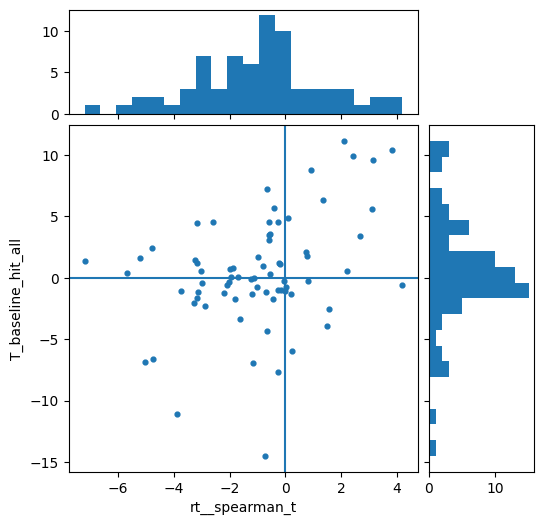

rt__spearman_t vs T_response_hit_all: n=72, rho=-0.536, p=1.2e-06


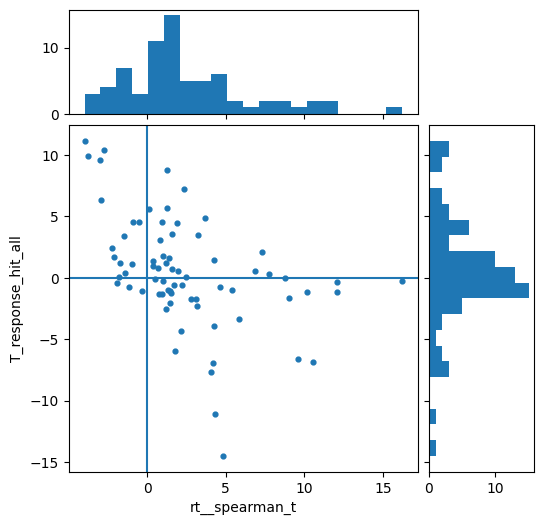

rt_bl__spearman_t vs T_baseline_hit_all: n=72, rho=-0.275, p=0.019


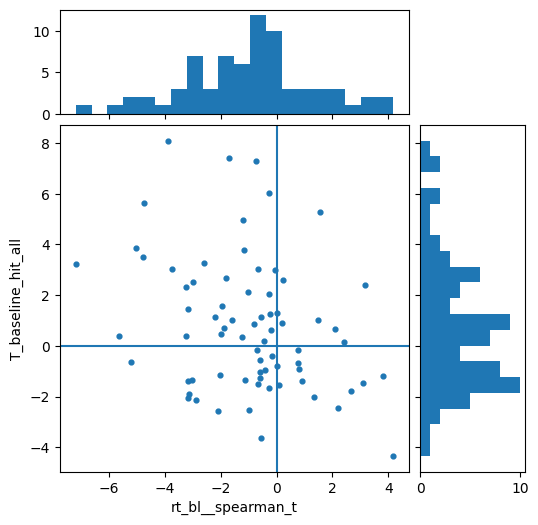

rt_bl__spearman_t vs T_response_hit_all: n=72, rho=-0.036, p=0.76


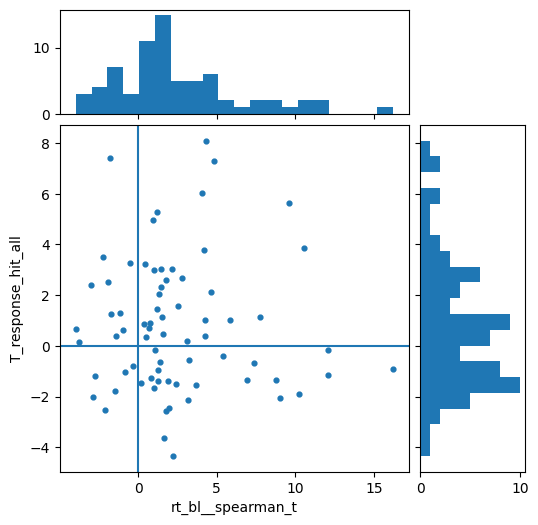

In [19]:
# ── Load data ─────────────────────────────────────────────────────────────────
sue = pd.read_pickle("/root/capsule/data/LCrecordings_combined_units/features_combined_beh_all.pkl").copy()

rt_df = features_combined[["session", "unit", "rt__spearman_t", "rt_bl__spearman_t"]].copy()
rt_df[["session", "unit"]] = rt_df[["session", "unit"]].astype(str)
rt_df["session_prefix"] = rt_df["session"].map(get_session_prefix)

sue[["session", "unit"]] = sue[["session", "unit"]].astype(str)
if "unit_id" in sue.columns and "unit" not in sue.columns:
    sue = sue.rename(columns={"unit_id": "unit"})
if "session_prefix" not in sue.columns:
    sue["session_prefix"] = sue["session"].map(get_session_prefix)

# ── Prefix overlap diagnostics ────────────────────────────────────────────────
rt_prefixes  = set(rt_df["session_prefix"].dropna().unique())
sue_prefixes = set(sue["session_prefix"].dropna().unique())
print(f"RT prefixes:     {len(rt_prefixes)}")
print(f"Sue prefixes:    {len(sue_prefixes)}")
print(f"Overlap:         {len(rt_prefixes & sue_prefixes)}")
print(f"In RT not Sue:   {sorted(rt_prefixes - sue_prefixes)[:10]}")
print(f"In Sue not RT:   {sorted(sue_prefixes - rt_prefixes)[:10]}")

# ── Merge ─────────────────────────────────────────────────────────────────────
rt_small = rt_df[["session_prefix", "unit", "rt__spearman_t", "rt_bl__spearman_t"]]
print("RT duplicates:", rt_small.duplicated(["session_prefix", "unit"]).sum())

sue_filtered = sue.merge(
    rt_small[["session_prefix", "unit"]].drop_duplicates(),
    on=["session_prefix", "unit"],
    how="inner",
    validate="many_to_one",
)
assert sue_filtered.duplicated(["session_prefix", "unit"]).sum() == 0, "Duplicates remain in sue_filtered"

sue_plus = sue_filtered.merge(
    rt_small,
    on=["session_prefix", "unit"],
    how="left",
    validate="one_to_one",
)
print(f"Merged rows:         {len(sue_plus)}")
print(f"RT missing rate:     {sue_plus['rt__spearman_t'].isna().mean():.3f}")
print(f"RT BL missing rate:  {sue_plus['rt_bl__spearman_t'].isna().mean():.3f}")

# ── Scatter with marginals ────────────────────────────────────────────────────
def scatter_with_marginals(x, y, x_label, y_label, bins=20):
    m = np.isfinite(x) & np.isfinite(y)
    x, y, n = x[m], y[m], m.sum()

    rho, p = (spearmanr(x, y) if n >= 3 else (np.nan, np.nan))
    print(f"{x_label} vs {y_label}: n={n}, rho={rho:.3f}, p={p:.2g}")

    fig = plt.figure(figsize=(6, 6))
    gs  = fig.add_gridspec(2, 2, width_ratios=(4, 1.2), height_ratios=(1.2, 4),
                           hspace=0.05, wspace=0.05)
    ax_scatter = fig.add_subplot(gs[1, 0])
    ax_histx   = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
    ax_histy   = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

    ax_scatter.scatter(x, y, s=12)
    ax_scatter.axhline(0); ax_scatter.axvline(0)
    ax_scatter.set_xlabel(x_label); ax_scatter.set_ylabel(y_label)
    ax_histx.hist(x, bins=bins); ax_histy.hist(y, bins=bins, orientation="horizontal")
    ax_histx.tick_params(labelbottom=False); ax_histy.tick_params(labelleft=False)

    plt.tight_layout(); 
    if SAVE_FIG:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        fname = f"scatter_{x_label}_vs_{y_label}"
        plt.savefig(FIG_DIR / f"{fname}.png", dpi=300, bbox_inches="tight")
        plt.savefig(FIG_DIR / f"{fname}.svg", dpi=300, bbox_inches="tight")
    plt.show()

my_cols  = ["rt__spearman_t", "rt_bl__spearman_t"]
sue_cols = ["T_baseline_hit_all", "T_response_hit_all"]

for my_col in my_cols:
    for sue_col in sue_cols:
        scatter_with_marginals(sue_plus[sue_col].to_numpy(), sue_plus[my_col].to_numpy(),
                               my_col, sue_col)